# Multilingual Distillation Demo

This demo will illustrate the basic workflow of the slang generation code accompanying the TACL paper *[A Computational Framework for Slang Generation](https://direct.mit.edu/tacl/article/doi/10.1162/tacl_a_00378/100687/A-Computational-Framework-for-Slang-Generation)* using slang definition data from Urban Dictionary (UD) and conventional definition data from WordNet.

To run this tutorial, you will need the following dependencies:

- Python 3
- Numpy
- Scipy
- tqdm
- NLTK
- Gensim
- PyTorch (torch)
- SBERT (sentence_transformers)
- [CatGO](https://github.com/zhewei-sun/CatGO)


In [41]:
import numpy as np
import torch
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

We first create a symbolic link pointing to the library. You will need to change the destination if your code sits in a different directory. 

In [2]:
! ln -s ../Code slanggen

ln: failed to create symbolic link 'slanggen/Code': File exists


CatGO is a library that optimizes and runs models of categorization and can be obtained [here](https://github.com/zhewei-sun/CatGO). Once you have downloaded the code, please link it by replacing the target directory of the simlink below. 

In [3]:
! ln -s ../../CatGO CatGO
import nltk
nltk.download('stopwords')

ln: failed to create symbolic link 'CatGO/CatGO': File exists


[nltk_data] Downloading package stopwords to /home/kefan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
from slanggen.util import *
from slanggen.dataloader import WN_Dataset, Dummy_ZH_Dataset, Urban_Dataset, OSD_Dataset, ZH_Dataset
from slanggen.encoder import FTEncoder, FTCachedEncoder
from slanggen.contrastive import SlangGenTrainer
from slanggen.model import SlangGenModel

/home/kefan/miniconda3/envs/slanggen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Specify a PyTorch device if necessary:

In [5]:
torch.cuda.set_device(0)

Load conventional definition data using the builtin dataloaders. The *.npy* file loaded below contains a pre-processed version of WordNet definition sentences for all words that appear in both WordNet and UD.

In [6]:
wn_data = WN_Dataset('wordnet_urban.npy')
print(wn_data)

Dataset Name: 
Total Definition Entries: 9759
Vocab Size: 1464



Load slang definition data. The *.npy* file loaded below is a pre-processed version of the data released in this repository.

In [7]:
OSD_wn_data = OSD_Dataset('OSD_data.npy', wn_data)
print(OSD_wn_data)

Dataset Name: 
Total Definition Entries: 2241
Vocab Size: 859



If you wish to use your own dataset, please create a dataloader object inheriting either *ConvDataset* or *SlangDataset* abstract classes found in *dataloader.py* and following the example data specifications in *dataloader.WN_Dataset* and *dataloader.Urban_Dataset*.

Now let's create a directory to store our results and load in some pre-generated data indices for train-test split:

In [8]:
shutil.rmtree('Results')  
create_directory('Results')

In [9]:
out_dir='Results/'

dataset_osd = OSD_wn_data
slang_inds_osd = DataIndex(np.load('train_ind_osd.npy'), np.load('dev_ind_osd.npy'), np.load('test_ind_osd.npy'))

The following encoder objects initializes a fastText encoder used for collaborative filtering. *FTEncoder* can be used to read in the original fastText embedding file. For efficiency, we have cached the words we need and use a cached encoder instead.

ft_encoder = FTEncoder('path to crawl-300d-2M-subword.vec')

In [10]:
ft_encoder = FTCachedEncoder('ft_embed_cache_Urban.pickle')

The following commands sets up the contrastive trainer and the slang generation model:

In [11]:
trainer_osd = SlangGenTrainer(dataset_osd, word_encoder=ft_encoder, out_dir=out_dir, verbose=True)

You can modify the 'embed_name' param below to choose the sense encoding model, here is a list of supported models:
- bert-base-nli-mean-tokens -> 'SBERT_contrastive' (default)
- sentence-t5-base -> 'SBERT_t5'
- paraphrase-multilingual-MiniLM-L12-v2 -> 'SBERT-multilingual-MiniLM-L12-v2'
- LaBSE -> 'SBERT_LaBSE'
- paraphrase-multilingual-mpnet-base-v2 -> 'SBERT_mpnet'
- intfloat/multilingual-e5-base -> 'SBERT_e5_base'
- intfloat/multilingual-e5-large -> 'SBERT_e5_large'

In [12]:
# This is the teacher model
model_osd = SlangGenModel(trainer_osd, data_dir=out_dir, embed_name='SBERT_contrastive')
params = {'embed_name':'SBERT_contrastive', 'out_name':'predictions', 'model':'cf_prototype_5', 'prior':None, 'prior_name':'uniform', 'contr_params':None}

Invoke *model.train_contrastive* to train the contrastively learned sense embedding model:

Note: you can set mode to 'head' to train only the triplet head, or 'whole' to train both the sense encoding and the head. Also it's optional to change the fold_name if using a new dataset.

In [13]:
model_osd.train_contrastive(slang_inds_osd, fold_name='osd_wn', params=params, mode='whole')

Generating contrative pairs...


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 112/112 [00:16<00:00,  6.64it/s]


Complete!
Training contrastive model with whole model
Generating triplet data for contrastive training...
Sampled 102450 Triplets
Sampled 6270 Triplets
Complete!


/home/kefan/miniconda3/envs/slanggen/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Epoch 1/4 - Training: 100%|████████████████████████████████████████████████████████████████████| 12802/12802 [02:52<00:00, 74.41it/s]


Epoch 1 average training loss: 0.6350


...

Epoch 4 average training loss: 0.3993


Epoch 4/4 - Validation: 100%|██████████████████████████████████████████████████████████████████████| 784/784 [00:10<00:00, 78.22it/s]


Epoch 4 average validation loss: 0.5955
New best model saved with validation loss: 0.5955
Training completed. Best validation loss: 0.5955
Cleared GPU cache before loading model


/home/kefan/miniconda3/envs/slanggen/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Encoding sense definitions...
Complete!


Once the contrastive represention has been trained. We run categorization models to perform few-shot learning:

In [14]:
model_osd.train_categorization(slang_inds_osd, fold_name='osd_wn', params=params)

Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.60s/it]


In [15]:
results_osd = model_osd.get_results(fold_name='osd_wn', mode='train', params=params)

We can compute the training AUC as follows. You should have a high AUC of >0.95.

In [16]:
N_train_dev_osd = dataset_osd.N_total - slang_inds_osd.test.shape[0]
train_rankings_osd = get_rankings(results_osd, np.arange(N_train_dev_osd), dataset_osd.vocab_ids[np.concatenate(slang_inds_osd)])
np.mean(get_roc(train_rankings_osd, dataset_osd.V))

0.8325837893296854

Perform prediction on the test portion of our dataset:

In [17]:
model_osd.predict_testset(slang_inds_osd, fold_name='osd_wn', params=params)

Params: {'embed_name': 'SBERT_contrastive', 'out_name': 'predictions', 'model': 'cf_prototype_5', 'prior': None, 'prior_name': 'uniform', 'contr_params': None}
Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 41.33it/s]


In [18]:
results_osd = model_osd.get_results(fold_name='osd_wn', mode='test', params=params)

The test set AUC is computed as below. You should be able to get above >0.75 on the test set.

In [19]:
inds = slang_inds_osd.test                       
labels = dataset_osd.vocab_ids                   
test_rankings_osd = get_rankings(results_osd, inds, labels)
np.mean(get_roc(test_rankings_osd, dataset_osd.V))

0.7424557032115172

Instead of passing all test examples during training. We can also pass in definition sentences and labels post-training as follows:

In [20]:
def collect_slang_sents(dataset, ind):
    sentences = []
    for i in ind:
        sentences.append(' '.join(simple_preprocess(dataset.slang_data[i].def_sent)))
    return sentences

In [21]:
test_sents_osd = collect_slang_sents(dataset_osd, slang_inds_osd.test)
test_labels_osd = dataset_osd.vocab_ids[slang_inds_osd.test]

In [22]:
model_osd.predict_from_definitions(test_sents_osd, test_labels_osd, fold_name='osd_wn', mode='testdef', params=params)

Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 41.07it/s]


In [23]:
results_osd = model_osd.get_results(fold_name='osd_wn', mode='testdef', params=params)

The test set AUC should be the same as expected:

In [24]:
inds = slang_inds_osd.test                       
labels = dataset_osd.vocab_ids                   
test_rankings_osd = get_rankings(results_osd, inds, labels)
np.mean(get_roc(test_rankings_osd, dataset_osd.V))

0.7424557032115172

In [25]:
# Now we initialize the student model
trainer_student = SlangGenTrainer(dataset_osd, word_encoder=ft_encoder, out_dir=out_dir, verbose=True)
model_student = SlangGenModel(trainer_student, data_dir=out_dir, embed_name='SBERT_mpnet')

In [26]:
# Setting up the training params
params = {
    'embed_name': 'SBERT_mpnet',
    'out_name': 'predictions',
    'model': 'prototype',
    'prior_name': 'uniform',
    'multilingual_params': {
        'train_batch_size': 8,
        'num_epochs': 4,
        'learning_rate': 1e-4,
        'head_dim': 768,
        'alpha': 0.5,  # Weight for distillation loss
        'outpath': 'SBERT_mpnet'
    }
}

In [27]:
# teacher_model_path = './' + out_dir + '/osd_wn/' + 'SBERT_data/SBERT_contrastive_with_head.pt'
teacher_model_path = './' + out_dir + '/osd_wn/' + 'SBERT_data/SBERT_contrastive_whole_finetuned.pt'

# Dataset
# parallel_data_path = 'sentence_pairs_EN_ZH.csv'
parallel_data_path = 'sentence_pairs_EN_RU.csv'

In [28]:
# Train the multilingual student model
model_student.train_multilingual_distillation(
    teacher_model_path=teacher_model_path,
    sentence_pairs_csv=parallel_data_path,
    fold_name='student',
    params=params,
    embed_name='SBERT_mpnet'
)

Training multilingual model with knowledge distillation
Loading teacher model...
Cleared GPU cache before loading model
Teacher model loaded successfully!
Loading parallel sentence pairs...
Loaded 1534 sentence pairs (1227 train, 307 dev)


Epoch 1/4 - Training: 100%|████████████████████████████████████████████████████████████████████████| 154/154 [00:02<00:00, 53.55it/s]


Epoch 1 - Train Loss: 0.0014 (MSE: 0.0014, Distill: 0.0013)


Epoch 1/4 - Validation: 100%|████████████████████████████████████████████████████████████████████████| 39/39 [00:00<00:00, 58.01it/s]


Epoch 1 - Val Loss: 0.0010 (MSE: 0.0011, Distill: 0.0010)
New best model saved with validation loss: 0.0010


...

Epoch 3 - Val Loss: 0.0008 (MSE: 0.0008, Distill: 0.0008)
New best model saved with validation loss: 0.0008


Epoch 4/4 - Training: 100%|████████████████████████████████████████████████████████████████████████| 154/154 [00:02<00:00, 54.11it/s]


Epoch 4 - Train Loss: 0.0007 (MSE: 0.0007, Distill: 0.0007)


Epoch 4/4 - Validation: 100%|████████████████████████████████████████████████████████████████████████| 39/39 [00:00<00:00, 57.89it/s]


Epoch 4 - Val Loss: 0.0008 (MSE: 0.0008, Distill: 0.0008)
New best model saved with validation loss: 0.0008
Training completed. Best validation loss: 0.0008
Multilingual student model saved to: Results//student/SBERT_data/SBERT_mpnet_multilingual_distilled.pt


In [29]:
# Test the result

wn_data = WN_Dataset('wordnet_urban.npy')
zh_conv_data = Dummy_ZH_Dataset('ZH_zh_conv_data.npy')
ru_conv_data = Dummy_ZH_Dataset('RU_ru_conv_data.npy')

OSD_wn_data = OSD_Dataset('OSD_data.npy', wn_data)
zh_data = ZH_Dataset('ZH_zh_slang_data.npy', zh_conv_data)
ru_data = ZH_Dataset('RU_ru_slang_data.npy', ru_conv_data)

dataset_en = OSD_wn_data
slang_inds_en = DataIndex(np.load('train_ind_osd.npy'), np.load('dev_ind_osd.npy'), np.load('test_ind_osd.npy'))

dataset_zh = zh_data
slang_inds_zh = DataIndex(np.load('train_ind_zh_zh.npy'), np.load('dev_ind_zh_zh.npy'), np.load('test_ind_zh_zh.npy'))

dataset_ru = ru_data
slang_inds_ru = DataIndex(np.load('train_ind_ru_ru.npy'), np.load('dev_ind_ru_ru.npy'), np.load('test_ind_ru_ru.npy'))


In [30]:
# A mpnet model before training
mpnet = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")  

test_idx_en = slang_inds_en.test
test_idx_zh = slang_inds_zh.test
test_idx_ru = slang_inds_ru.test

sim_en_pre = avg_slang_conv_sim(dataset_en, wn_data, mpnet, idx_subset=test_idx_en)
sim_zh_pre = avg_slang_conv_sim(dataset_zh, zh_conv_data, mpnet, idx_subset=test_idx_zh)
sim_ru_pre = avg_slang_conv_sim(dataset_ru, ru_conv_data, mpnet, idx_subset=test_idx_ru)

/home/kefan/miniconda3/envs/slanggen/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [31]:
# Distilled student model

sl_emb_en = get_finetuned_slang_emb(dataset_en, model_student, "student", params)
sim_en_post = avg_slang_conv_sim_after(dataset_en, wn_data, sl_emb_en, model_student, "student", params, idx_subset=test_idx_en)

sl_emb_zh = get_finetuned_slang_emb(dataset_zh, model_student, "student", params)
sim_zh_post = avg_slang_conv_sim_after(dataset_zh, zh_conv_data, sl_emb_zh, model_student, "student", params, idx_subset=test_idx_zh)

sl_emb_ru = get_finetuned_slang_emb(dataset_ru, model_student, "student", params)
sim_ru_post = avg_slang_conv_sim_after(dataset_ru, ru_conv_data, sl_emb_ru, model_student, "student", params, idx_subset=test_idx_ru)

Cleared GPU cache before loading model


In [32]:
print("EN pre-train sim:", sim_en_pre)
print("EN post-train sim:", sim_en_post)

print("ZH pre-train sim:", sim_zh_pre)
print("ZH post-train sim:", sim_zh_post)

print("RU pre-train sim:", sim_ru_pre)
print("RU post-train sim:", sim_ru_post)

EN pre-train sim: 0.22873411975645772
EN post-train sim: 0.6449710159518179
ZH pre-train sim: 0.747891693909963
ZH post-train sim: 0.9220390232404073
RU pre-train sim: 0.4381610924391063
RU post-train sim: 0.8273956829851324


In [33]:
!mkdir -p Results/test_en/SBERT_data
!mkdir -p Results/test_zh/SBERT_data
!mkdir -p Results/test_ru/SBERT_data

params = {'embed_name':'SBERT_mpnet', 'out_name':'predictions', 'model':'prototype', 'prior':None, 'prior_name':'uniform', 'contr_params':None}

!cp Results/student/SBERT_data/SBERT_mpnet_multilingual_distilled.pt Results/test_en/SBERT_data/ 

trainer_test_en = SlangGenTrainer(OSD_wn_data, word_encoder=ft_encoder, out_dir=out_dir, verbose=True)
model_test_en   = SlangGenModel(trainer_test_en, data_dir=out_dir, embed_name='SBERT_mpnet')

trainer_test_en.get_trained_embeddings(slang_inds_osd, fold_name='test_en', model_path='SBERT_mpnet')

model_test_en.train_categorization(slang_inds_osd, fold_name='test_en', params=params)
results_en = model_test_en.get_results(fold_name='test_en', mode='train', params=params)

print('Performance on train split - EN')
N_train_dev_en = OSD_wn_data.N_total - slang_inds_osd.test.shape[0]
train_rankings_en = get_rankings(results_en, np.arange(N_train_dev_en), OSD_wn_data.vocab_ids[np.concatenate(slang_inds_osd)])
np.mean(get_roc(train_rankings_en, OSD_wn_data.V))

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Cleared GPU cache before loading model
Encoding sense definitions...
Complete!
Pre-processing Distances...


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 859/859 [00:11<00:00, 71.81it/s]


Pre-processing Complete!
Optimizing Kernels...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.12it/s]

Performance on train split - EN


0.6822143101426618

In [34]:
model_test_en.predict_testset(slang_inds_osd, fold_name='test_en', params=params)
results_en = model_test_en.get_results(fold_name='test_en', mode='test', params=params)

print('Performance on test split - EN')
inds = slang_inds_osd.test                     
labels = OSD_wn_data.vocab_ids                 
test_rankings_en = get_rankings(results_en, inds, labels)
np.mean(get_roc(test_rankings_en, OSD_wn_data.V))

Params: {'embed_name': 'SBERT_mpnet', 'out_name': 'predictions', 'model': 'exemplar', 'prior': None, 'prior_name': 'uniform', 'contr_params': None}
Pre-processing Distances...


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 859/859 [00:02<00:00, 409.70it/s]


Pre-processing Complete!
Optimizing Kernels...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 99.61it/s]

Performance on test split - EN


0.6849806201550387

In [35]:
!cp Results/student/SBERT_data/SBERT_mpnet_multilingual_distilled.pt Results/test_zh/SBERT_data/

trainer_test_zh = SlangGenTrainer(zh_data, word_encoder=ft_encoder, out_dir=out_dir, verbose=True)
model_test_zh   = SlangGenModel(trainer_test_zh, data_dir=out_dir, embed_name='SBERT_mpnet')

trainer_test_zh.get_trained_embeddings(slang_inds_zh, fold_name='test_zh', model_path='SBERT_mpnet')

model_test_zh.train_categorization(slang_inds_zh, fold_name='test_zh', params=params)
results_zh = model_test_zh.get_results(fold_name='test_zh', mode='train', params=params)

print('Performance on train split - ZH')
N_train_dev_zh = zh_data.N_total - slang_inds_zh.test.shape[0]
train_rankings_zh = get_rankings(results_zh, np.arange(N_train_dev_zh), zh_data.vocab_ids[np.concatenate(slang_inds_zh)])
np.mean(get_roc(train_rankings_zh, zh_data.V))

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Cleared GPU cache before loading model
Encoding sense definitions...
Complete!
Pre-processing Distances...


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 643/643 [00:01<00:00, 530.30it/s]


Pre-processing Complete!
Optimizing Kernels...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  8.99it/s]

Performance on train split - ZH


0.9158995784738669

In [36]:
model_test_zh.predict_testset(slang_inds_zh, fold_name='test_zh', params=params)
results_zh = model_test_zh.get_results(fold_name='test_zh', mode='test', params=params)

print('Performance on test split - ZH')
inds = slang_inds_zh.test                      
labels = zh_data.vocab_ids                 
test_rankings_zh = get_rankings(results_zh, inds, labels)
np.mean(get_roc(test_rankings_zh, zh_data.V))

Params: {'embed_name': 'SBERT_mpnet', 'out_name': 'predictions', 'model': 'exemplar', 'prior': None, 'prior_name': 'uniform', 'contr_params': None}
Pre-processing Distances...


100%|████████████████████████████████████████████████████████████████████████████████████████████| 643/643 [00:00<00:00, 2594.32it/s]


Pre-processing Complete!
Optimizing Kernels...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 217.25it/s]

Performance on test split - ZH


0.936583850931677

In [37]:
!cp Results/student/SBERT_data/SBERT_mpnet_multilingual_distilled.pt Results/test_ru/SBERT_data/

trainer_test_ru = SlangGenTrainer(ru_data, word_encoder=ft_encoder, out_dir=out_dir, verbose=True)
model_test_ru   = SlangGenModel(trainer_test_ru, data_dir=out_dir, embed_name='SBERT_mpnet')

trainer_test_ru.get_trained_embeddings(slang_inds_ru, fold_name='test_ru', model_path='SBERT_mpnet')

model_test_ru.train_categorization(slang_inds_ru, fold_name='test_ru', params=params)
results_ru = model_test_ru.get_results(fold_name='test_ru', mode='train', params=params)

print('Performance on train split - RU')
N_train_dev_ru = ru_data.N_total - slang_inds_ru.test.shape[0]
train_rankings_ru = get_rankings(results_ru, np.arange(N_train_dev_ru), ru_data.vocab_ids[np.concatenate(slang_inds_ru)])
np.mean(get_roc(train_rankings_ru, ru_data.V))

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Cleared GPU cache before loading model
Encoding sense definitions...
Complete!
Pre-processing Distances...


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 961/961 [00:03<00:00, 273.66it/s]


Pre-processing Complete!
Optimizing Kernels...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.93it/s]

Performance on train split - RU


0.6668933732130758

In [38]:
model_test_ru.predict_testset(slang_inds_ru, fold_name='test_ru', params=params)
results_ru = model_test_ru.get_results(fold_name='test_ru', mode='test', params=params)

print('Performance on test split - RU')
inds = slang_inds_ru.test                      
labels = ru_data.vocab_ids                 
test_rankings_ru = get_rankings(results_ru, inds, labels)
np.mean(get_roc(test_rankings_ru, ru_data.V))

Params: {'embed_name': 'SBERT_mpnet', 'out_name': 'predictions', 'model': 'exemplar', 'prior': None, 'prior_name': 'uniform', 'contr_params': None}
Pre-processing Distances...


100%|████████████████████████████████████████████████████████████████████████████████████████████| 961/961 [00:00<00:00, 1486.64it/s]


Pre-processing Complete!
Optimizing Kernels...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 145.91it/s]

Performance on test split - RU


0.6677085907855138

In [50]:
# Debugging

def inspect_samples(dataset, conv_ds, slang_inds, model_obj, fold_name, params, k=5, seed=42, topk=5):
    rng = np.random.default_rng(seed)
    test_ids = slang_inds.test
    pick = rng.choice(test_ids, size=min(k, len(test_ids)), replace=False)

    results = model_obj.get_results(fold_name=fold_name, mode='test', params=params)

    rows = []
    for idx in pick:
        entry = dataset.slang_data[idx]
        slang_text = entry.def_sent
        conv_text  = get_conv_def(entry.word, conv_ds)
        if conv_text is None:
            continue

        # conv-slang cos sim
        sl_emb = model_obj.trainer.get_testtime_embeddings([slang_text], fold_name=fold_name, model_path=params['embed_name'])[0]
        cv_emb = model_obj.trainer.get_testtime_embeddings([conv_text],  fold_name=fold_name, model_path=params['embed_name'])[0]
        sim = cos_sim(sl_emb, cv_emb)

        local_i = int(np.where(test_ids == idx)[0][0])
        row = results[local_i]

        true_label = dataset.vocab_ids[idx]
        rank = int(np.where(np.argsort(row)[::-1] == true_label)[0][0]) + 1
        top_pred = np.argsort(row)[::-1][:topk]

        rows.append({
            'global_idx': int(idx),
            'word': str(entry.word),
            'sim': float(sim),
            'rank': rank,
            'top_pred': top_pred.tolist()
        })

    return rows

rows_en = inspect_samples(dataset_osd, wn_data, slang_inds_osd, model_test_en, 'test_en', params, k=300, seed=0)
rows_zh = inspect_samples(zh_data, zh_conv_data, slang_inds_zh, model_test_zh, 'test_zh', params, k=300, seed=0)
rows_ru = inspect_samples(ru_data, ru_conv_data, slang_inds_ru, model_test_ru, 'test_ru', params, k=300, seed=0)

# print(rows_en)

# print(rows_zh)

# print(rows_ru)

EN Spearman(sim, -rank): 0.568 (p=5.1e-27)
EN Pearson(sim, 1/rank): 0.397 (p=9.7e-13)


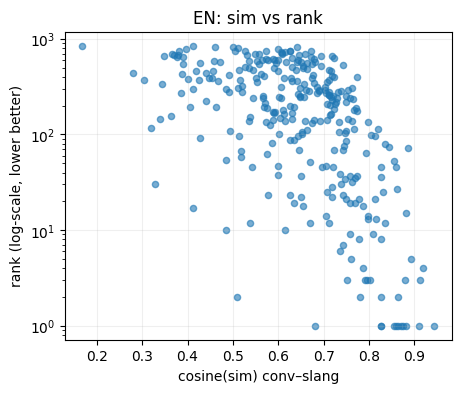

ZH Spearman(sim, -rank): 0.783 (p=1.1e-16)
ZH Pearson(sim, 1/rank): 0.598 (p=1.5e-08)


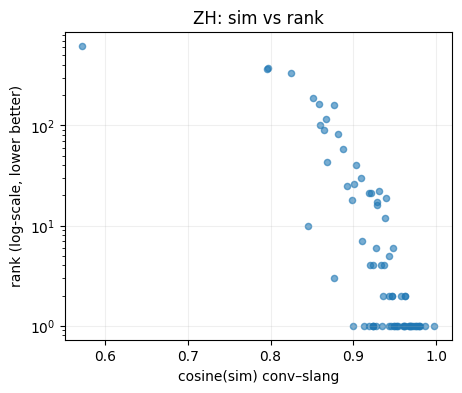

RU Spearman(sim, -rank): 0.875 (p=2.7e-46)
RU Pearson(sim, 1/rank): 0.495 (p=3.3e-10)


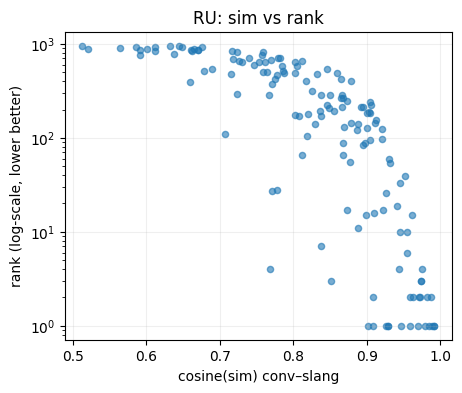

In [51]:
def visualize_rows(rows, title='EN'):
    df = pd.DataFrame(rows)  
    rho_s, p_s = spearmanr(df['sim'], -df['rank'])
    rho_p, p_p = pearsonr(df['sim'], 1.0/df['rank'])
    print(f'{title} Spearman(sim, -rank): {rho_s:.3f} (p={p_s:.2g})')
    print(f'{title} Pearson(sim, 1/rank): {rho_p:.3f} (p={p_p:.2g})')

    plt.figure(figsize=(5,4))
    plt.scatter(df['sim'], df['rank'], s=20, alpha=0.6)
    plt.yscale('log')
    plt.xlabel('cosine(sim) conv–slang')
    plt.ylabel('rank (log-scale, lower better)')
    plt.title(f'{title}: sim vs rank')
    plt.grid(alpha=0.2)
    plt.show()

visualize_rows(rows_en, title='EN')
visualize_rows(rows_zh, title='ZH')
visualize_rows(rows_ru, title='RU')